# All Bark and No Byte?

**Does a country's sentiment about digital transformation relate to real-world improvements in its internet infrastructure?**

| | |
|---|---|
| **SDG** | SDG 9 - Industry, innovation and infrastructure (target 9.c: universal, affordable access to ICT) |
| **GA theme** | *Restoring trust, managing transformation* |
| **Connection** | Digital transformation is the "transformation" half of the theme and the core of SDG 9. The "trust" half raises the direct question: do the countries that *talk* about digital progress actually *deliver* it? Perceived corruption links the two, because it erodes institutional trust and undermines infrastructure investment. |

**Q1 (exploratory).** How does the sentiment of digital-transformation language in General Debate speeches relate to a country's internet access rates and mobile subscriptions over time?

**Q2 (predictive).** To what extent can that sentiment predict the change in a country's internet access rate *in the following year*, and does perceived corruption moderate the relationship?

### How the question is measured

| Concept | Operationalisation | Source |
|---|---|---|
| **Digital-transformation talk** | Sentences that use vocabulary from the `digital_infrastructure` or `internet_and_access` lexicons (broadband, connectivity, internet, ICT, digital divide, social media, ...) | UNGDC speeches, `speeches_features.csv` |
| **Sentiment** | Mean VADER compound score (-1 to +1) of those sentences, per speech | same |
| **Topic share (salience)** | Digital sentences as a share of all sentences in the speech | same |
| **Framing** | Share of digital sentences that also use *promise* vocabulary ("opportunity", "empower", "leapfrog", ...) | same |
| **Internet access** | Individuals using the Internet, % of population | World Bank WDI |
| **Mobile subscriptions** | Mobile cellular subscriptions per 100 people | World Bank WDI |
| **Perceived corruption** | "Perceptions of corruption", 0-1, **higher = more corrupt**, 2005 onward | World Happiness Report |

Every speech is one country-year, so everything joins on `(country_code, year)`.

## 0. Setup

In [2]:
import logging
import warnings

import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from matplotlib.colors import LinearSegmentedColormap
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, r2_score
from sklearn.model_selection import GroupKFold

from un_general_debate_analysis.external import load_all
from un_general_debate_analysis.preprocessing import OUT_DIR

warnings.filterwarnings("ignore", category=FutureWarning)
logging.getLogger("matplotlib.font_manager").setLevel(logging.ERROR)  # no "semibold" font in some setups
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 200)
pd.set_option("display.float_format", lambda v: f"{v:,.3f}")

# one palette for the whole notebook (same as the other SDG 9 notebooks)
SERIES = ["#2a78d6", "#eb6834", "#1baf7a", "#eda100", "#e87ba4", "#008300", "#4a3aa7", "#e34948"]
BLUE, ORANGE, AQUA, YELLOW, MAGENTA, GREEN, VIOLET, RED = SERIES
INK, INK_SOFT, GRID = "#0b0b0b", "#52514e", "#dddcd7"
SEQ_BLUE = ["#cde2fb", "#9ec5f4", "#6da7ec", "#3987e5", "#256abf", "#184f95", "#0d366b"]
DIVERGING = LinearSegmentedColormap.from_list("bark_byte", [ORANGE, "#ffffff", BLUE])

mpl.rcParams.update({
    "figure.dpi": 110, "savefig.dpi": 110, "figure.facecolor": "white",
    "axes.facecolor": "white", "axes.edgecolor": GRID, "axes.labelcolor": INK_SOFT,
    "axes.titlesize": 12, "axes.titleweight": "semibold", "axes.titlecolor": INK,
    "axes.titlelocation": "left", "axes.titlepad": 10, "axes.labelsize": 10,
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.grid": True, "grid.color": GRID, "grid.linewidth": 0.6, "grid.alpha": 0.9,
    "xtick.color": INK_SOFT, "ytick.color": INK_SOFT, "xtick.labelsize": 9, "ytick.labelsize": 9,
    "legend.frameon": False, "legend.fontsize": 9, "lines.linewidth": 2.0, "font.size": 10,
})


def finish(ax, title=None, subtitle=None, xlabel=None, ylabel=None, legend=False, grid="y"):
    """Title, optional subtitle, axis labels and a recessive grid, applied the same way everywhere."""
    if title:
        ax.set_title(title, pad=16 if subtitle else 10)
    if subtitle:
        ax.text(0, 1.01, subtitle, transform=ax.transAxes, fontsize=8.5, color=INK_SOFT, va="bottom")
    ax.set_xlabel(xlabel or "")
    ax.set_ylabel(ylabel or "")
    ax.set_axisbelow(True)
    ax.grid(False)
    if grid:
        ax.grid(True, axis=grid)
    if legend and ax.get_legend_handles_labels()[0]:
        ax.legend(loc="best")
    return ax


def zscore(s):
    return (s - s.mean()) / s.std()


def mean_ci(g, col):
    """Mean and 95% half-width of ``col`` within each group of a groupby."""
    a = g[col].agg(["mean", "std", "count"])
    a["ci"] = 1.96 * a["std"] / np.sqrt(a["count"])
    return a

## 1. Data

`speeches_features.csv` already scores the two digital lexicons separately (`digital_infrastructure` = the *pipes*: broadband, fibre, connectivity; `internet_and_access` = the *use*: internet, ICT, digital divide, social media). We pool them into one **digital-transformation** signal by adding their sentence counts and taking the sentence-weighted mean of their sentiment.

A sentence that mentions both lexicons is counted twice, which is a small approximation; the pooled speech count (1,817) matches an exact union.

In [3]:
features = pd.read_csv(OUT_DIR / "speeches_features.csv")
external = load_all(verbose=False)          # World Bank + WHR + EGDI, keyed on (country_code, year)

DI, IA = "digital_infrastructure", "internet_and_access"
speech = features[["country_code", "country", "year", "region_name", "n_sentences"]].copy()

n_di, n_ia = features[f"{DI}_sentences"], features[f"{IA}_sentences"]
speech["dig_n"] = n_di + n_ia                                             # digital sentences (pooled)
speech["mention"] = (speech["dig_n"] > 0).astype(int)                      # said anything digital?
speech["salience"] = speech["dig_n"] / speech["n_sentences"]               # topic share
said = speech["dig_n"].where(speech["dig_n"] > 0)                          # NaN when nothing was said
speech["sentiment"] = (n_di * features[f"{DI}_sentiment"] + n_ia * features[f"{IA}_sentiment"]) / said
speech["promise"] = (features[f"{DI}_frame_promise_sentences"] + features[f"{IA}_frame_promise_sentences"]) / said

panel = speech.merge(external, on=["country_code", "year"], how="left")


def ahead(col, k, name):
    """``col`` measured k years after the speech year, aligned to the speech year."""
    s = external[["country_code", "year", col]].copy()
    s["year"] -= k
    return s.rename(columns={col: name})


# A speech is delivered in September of year t, so t -> t+1 is the first full year after it.
for col, short in [("internet_users_pct", "internet"), ("mobile_per_100", "mobile")]:
    panel = panel.merge(ahead(col, 1, f"{short}_t1"), on=["country_code", "year"], how="left")
    panel[f"{short}_gain_next"] = panel[f"{short}_t1"] - panel[col]          # percentage points / subs per 100

panel["log_gdp"] = np.log(panel["gdp_per_capita_ppp"])
modern = panel[panel["year"].between(2000, 2024)].copy()                    # 2025 has no connectivity data yet

print(f"{len(speech):,} speeches, {speech['country_code'].nunique()} countries, {speech['year'].min()}-{speech['year'].max()}")
print(f"{speech['mention'].sum():,} speeches ({speech['mention'].mean():.0%}) contain at least one digital sentence; "
      f"median number of such sentences when they do: {speech.loc[speech['mention'] == 1, 'dig_n'].median():.0f}")
modern[["mention", "salience", "sentiment", "promise", "internet_users_pct", "mobile_per_100",
        "internet_gain_next", "perceived_corruption"]].describe().T[["count", "mean", "std", "min", "50%", "max"]]

11,141 speeches, 200 countries, 1946-2025
1,817 speeches (16%) contain at least one digital sentence; median number of such sentences when they do: 1


,count,mean,std,min,50%,max
mention,"4,793.000",0.245,0.430,0.000,0.000,1.000
salience,"4,793.000",0.005,0.013,0.000,0.000,0.213
sentiment,"1,174.000",0.276,0.458,-0.988,0.359,0.976
promise,"1,174.000",0.225,0.375,0.000,0.000,1.000
internet_users_pct,"4,566.000",39.347,32.383,0.000,32.900,100.000
mobile_per_100,"4,632.000",79.668,49.587,0.000,85.503,574.152
internet_gain_next,"4,349.000",2.643,3.344,-20.927,1.819,40.444
perceived_corruption,"2,169.000",0.746,0.183,0.035,0.799,0.983


**Most speeches say nothing digital, and those that do say very little.** Only about one speech in six contains a digital sentence and the median is a single sentence, so a speech's "sentiment" is usually the VADER score of *one* sentence. That is noisy, and it shapes the design: sentiment only exists when a country spoke, so the plots below either use the speeches that say something or use measures defined for every speech (mention, salience).

## 2. Q1 - Exploratory: does the tone of digital talk track connectivity?

### 2.1 Bark and byte over time

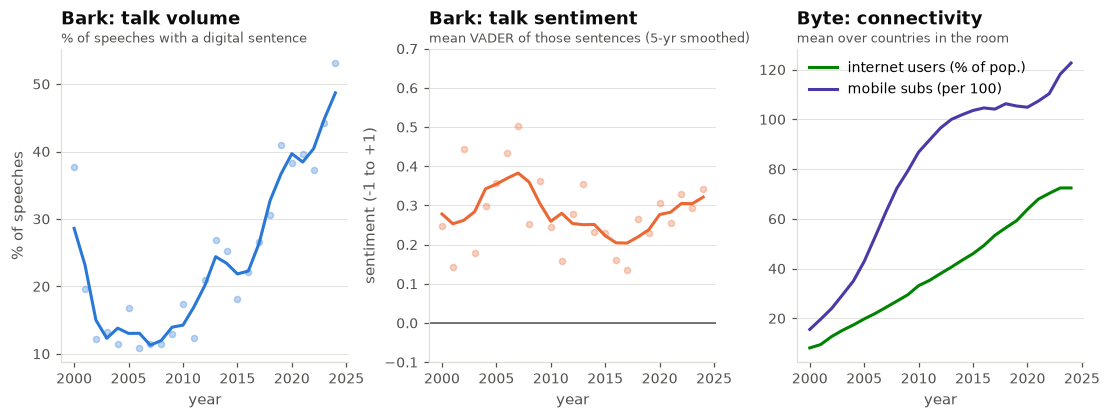

2000-04 -> 2020-24:  talk 19% -> 43% of speeches | sentiment 0.26 -> 0.31 | internet 13% -> 69% | mobile 25 -> 113 per 100


In [98]:
yr = modern.groupby("year").agg(talk=("mention", "mean"), sentiment=("sentiment", "mean"),
                                internet=("internet_users_pct", "mean"), mobile=("mobile_per_100", "mean"),
                                corruption=("perceived_corruption", "mean"),
                                gdp=("whr_log_gdp_pc","mean")
                                )


yr["talk_s"] = yr["talk"].rolling(3, center=True, min_periods=2).mean()
yr["sent_s"] = yr["sentiment"].rolling(5, center=True, min_periods=3).mean()

fig, axes = plt.subplots(1, 3, figsize=(12, 3.7), sharex=True, gridspec_kw={"wspace": 0.28})

ax = axes[0]
ax.plot(yr.index, 100 * yr["talk"], "o", color=BLUE, alpha=0.3, ms=4)
ax.plot(yr.index, 100 * yr["talk_s"], color=BLUE)
finish(ax, "Bark: talk volume", "% of speeches with a digital sentence", ylabel="% of speeches")

ax = axes[1]
ax.axhline(0, color=INK_SOFT, lw=1)
ax.plot(yr.index, yr["sentiment"], "o", color=ORANGE, alpha=0.3, ms=4)
ax.plot(yr.index, yr["sent_s"], color=ORANGE)
ax.set_ylim(-0.1, 0.7)
finish(ax, "Bark: talk sentiment", "mean VADER of those sentences (5-yr smoothed)", ylabel="sentiment (-1 to +1)")

ax = axes[2]
ax.plot(yr.index, yr["internet"], color=GREEN, label="internet users (% of pop.)")
ax.plot(yr.index, yr["mobile"], color=VIOLET, label="mobile subs (per 100)")
finish(ax, "Byte: connectivity", "mean over countries in the room", legend=True)

plt.savefig("EDA.png", dpi=300, bbox_inches="tight")

for ax in axes:
    ax.set_xlabel("year")
plt.show()



era_gap = yr.loc[2020:2024].mean() - yr.loc[2000:2004].mean()
print(f"2000-04 -> 2020-24:  talk {100*yr.loc[2000:2004,'talk'].mean():.0f}% -> {100*yr.loc[2020:2024,'talk'].mean():.0f}% of speeches | "
      f"sentiment {yr.loc[2000:2004,'sentiment'].mean():.2f} -> {yr.loc[2020:2024,'sentiment'].mean():.2f} | "
      f"internet {yr.loc[2000:2004,'internet'].mean():.0f}% -> {yr.loc[2020:2024,'internet'].mean():.0f}% | "
      f"mobile {yr.loc[2000:2004,'mobile'].mean():.0f} -> {yr.loc[2020:2024,'mobile'].mean():.0f} per 100")



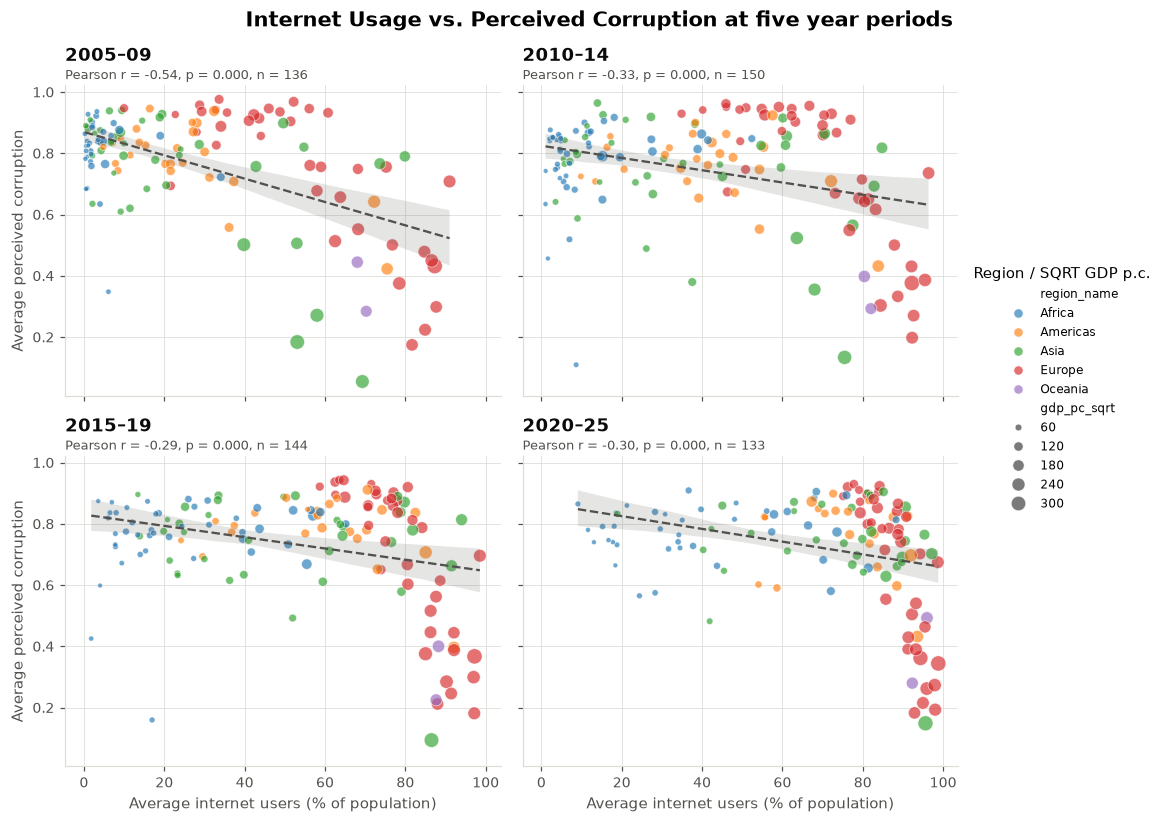

In [102]:
periods = ["2005–09", "2010–14", "2015–19", "2020–25"]

data = modern.loc[
    modern["year"].between(2005, 2025),
    ["country_code", "region_name", "year", "internet_users_pct", "perceived_corruption", "whr_log_gdp_pc"]
].dropna(subset=["internet_users_pct", "perceived_corruption"]).copy()

data["gdp_pc"] = np.exp(data["whr_log_gdp_pc"])
data["gdp_pc_sqrt"] = np.sqrt(np.exp(data["whr_log_gdp_pc"]))

data["period"] = pd.cut(
    data["year"],
    bins=[2004, 2009, 2014, 2019, 2025],
    labels=periods,
)

period_data = (
    data.groupby(["period", "country_code", "region_name"], observed=True)
    [["internet_users_pct", "perceived_corruption", "gdp_pc_sqrt"]]
    .mean()
    .reset_index()
)

hue_order = sorted(period_data["region_name"].unique())
palette = dict(zip(hue_order, sns.color_palette(n_colors=len(hue_order))))

fig, axes = plt.subplots(2, 2, figsize=(11, 8), sharex=True, sharey=True)

for ax, period in zip(axes.flat, periods):
    subset = period_data[period_data["period"].eq(period)]

    sns.scatterplot(
        data=subset,
        x="internet_users_pct",
        y="perceived_corruption",
        hue="region_name",
        hue_order=hue_order,
        palette=palette,
        size="gdp_pc_sqrt",
        sizes=(10, 100),
        alpha=0.65,
        edgecolor="white",
        linewidth=0.5,
        ax=ax,
        legend=(period == periods[0]),
    )

    subtitle = ""
    if len(subset) > 1:
        sns.regplot(
            data=subset,
            x="internet_users_pct",
            y="perceived_corruption",
            scatter=False,
            color=INK_SOFT,
            line_kws={"linestyle": "--", "linewidth": 1.5},
            ax=ax,
        )
        rho, p = stats.pearsonr(subset["internet_users_pct"], subset["perceived_corruption"])
        subtitle = f"Pearson r = {rho:+.2f}, p = {p:.3f}, n = {len(subset)}"

    finish(
        ax,
        f"{period}",
        subtitle,
        xlabel="Average internet users (% of population)",
        ylabel="Average perceived corruption" if ax in axes[:, 0] else "",
        grid="both",
    )

handles, labels = axes.flat[0].get_legend_handles_labels()
axes.flat[0].legend_.remove()
fig.suptitle(
    "Internet Usage vs. Perceived Corruption at five year periods",
    fontsize=14,
    fontweight="bold",
    y=0.93,
)

fig.legend(
    handles,
    labels,
    loc="center left",
    bbox_to_anchor=(0.8, 0.5),
    fontsize=8,
    title="Region / SQRT GDP p.c.",
    frameon=False,
)

plt.tight_layout(rect=[0, 0, 0.81, 0.95])
plt.savefig("corruption_it_usage", bbox_inches="tight")
plt.show()

Pearson correlations:


,Talk volume,Sentiment,Internet access,Mobile subscriptions,Perceived Corruption,Log_gdp
Talk volume,1.000,-0.111,0.760,0.553,-0.787,0.456
Sentiment,-0.111,1.000,-0.116,-0.144,0.385,-0.069
Internet access,0.760,-0.116,1.000,0.922,-0.733,0.300
Mobile subscriptions,0.553,-0.144,0.922,1.000,-0.494,0.057
Perceived Corruption,-0.787,0.385,-0.733,-0.494,1.000,-0.682
Log_gdp,0.456,-0.069,0.300,0.057,-0.682,1.000


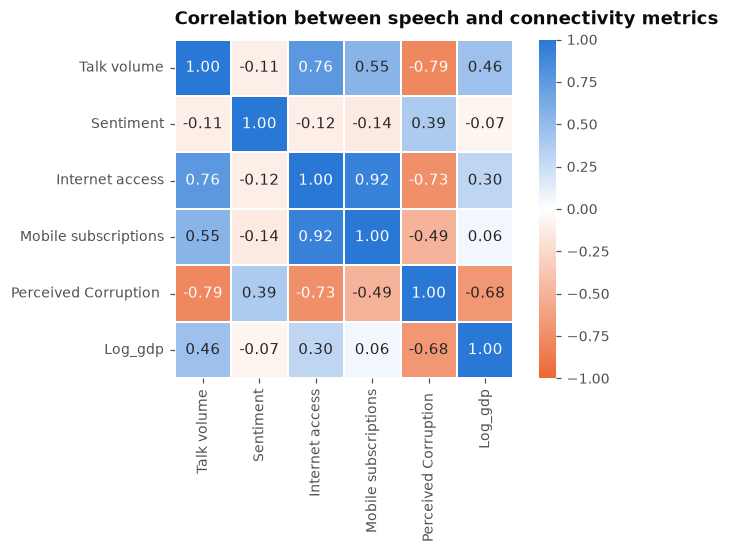

In [100]:
metrics = yr[["talk", "sentiment", "internet", "mobile", "corruption","gdp"]].copy()
metrics = metrics.rename(columns={
    "talk": "Talk volume",
    "sentiment": "Sentiment",
    "internet": "Internet access",
    "mobile": "Mobile subscriptions",
    "corruption" : "Perceived Corruption ",
    "gdp": "Log_gdp"
})

# Pearson correlations
corr = metrics.corr(method="pearson")
print("Pearson correlations:")
display(corr.round(3))


# Visualise the Pearson correlations
fig, ax = plt.subplots(figsize=(6, 4))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap=DIVERGING,
    vmin=-1,
    vmax=1,
    center=0,
    square=True,
    linewidths=1,
    linecolor="white",
    ax=ax,
)
finish(ax, "Correlation between speech and connectivity metrics", grid=None)
plt.show()


**The volume of talk and the connectivity of the world rise together; the tone does not move.** Between 2000-04 and 2020-24 the share of speeches with a digital sentence goes from 19% to 43%, internet use in the countries in the room from 13% to 69% of the population and mobile subscriptions from 25 to 113 per 100 people. Sentiment stays in a band around +0.2 to +0.4 the whole time (0.26 to 0.31), with no trend. Two shared upward lines are a coincidence of timelines rather than evidence of a link, so the next plots compare countries *within* the same period.

The spike in 2000-01 is the Millennium Summit / "information technology" moment; talk then collapses before the smartphone era brings it back.

### 2.2 Are the better-connected countries also the more upbeat?

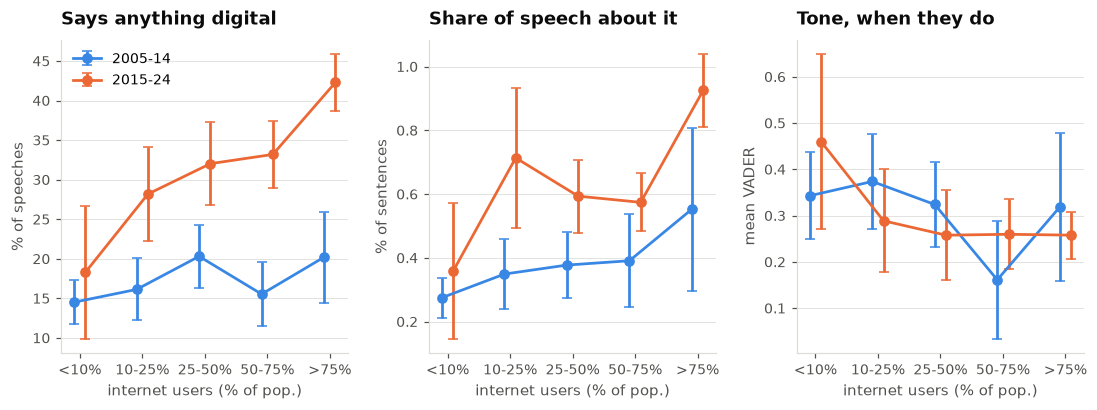

In [4]:
d = modern[modern["year"].between(2005, 2024) & modern["internet_users_pct"].notna()].copy()
d["level"] = pd.cut(d["internet_users_pct"], [0, 10, 25, 50, 75, 100], include_lowest=True,
                    labels=["<10%", "10-25%", "25-50%", "50-75%", ">75%"])
d["era"] = np.where(d["year"] < 2015, "2005-14", "2015-24")

fig, axes = plt.subplots(1, 3, figsize=(12, 3.7), gridspec_kw={"wspace": 0.28})
panels = [("mention", "Says anything digital", "% of speeches", 100),
          ("salience", "Share of speech about it", "% of sentences", 100),
          ("sentiment", "Tone, when they do", "mean VADER", 1)]
for ax, (col, title, ylab, k) in zip(axes, panels):
    for (era, sub), color, off in zip(d.groupby("era"), [SEQ_BLUE[3], ORANGE], [-0.09, 0.09]):
        a = mean_ci(sub.groupby("level", observed=True), col)
        x = np.arange(len(a)) + off
        ax.errorbar(x, k * a["mean"], yerr=k * a["ci"], fmt="o-", color=color, capsize=3, lw=1.8, label=era)
    ax.set_xticks(range(5), ["<10%", "10-25%", "25-50%", "50-75%", ">75%"])
    finish(ax, title, xlabel="internet users (% of pop.)", ylabel=ylab, legend=(col == "mention"))
plt.show()

Comparing countries at the *same* level of connectivity, the two eras look very different in **how much** countries say (the 2015-24 line sits well above 2005-14 everywhere, and rises with connectivity, from roughly 18% of speeches in the least connected group to 42% in the most connected), but very similar in **how positively** they say it: the tone panel is flat, and the confidence intervals overlap at almost every level. The better-connected talk more, not more warmly.

### 2.3 Country by country

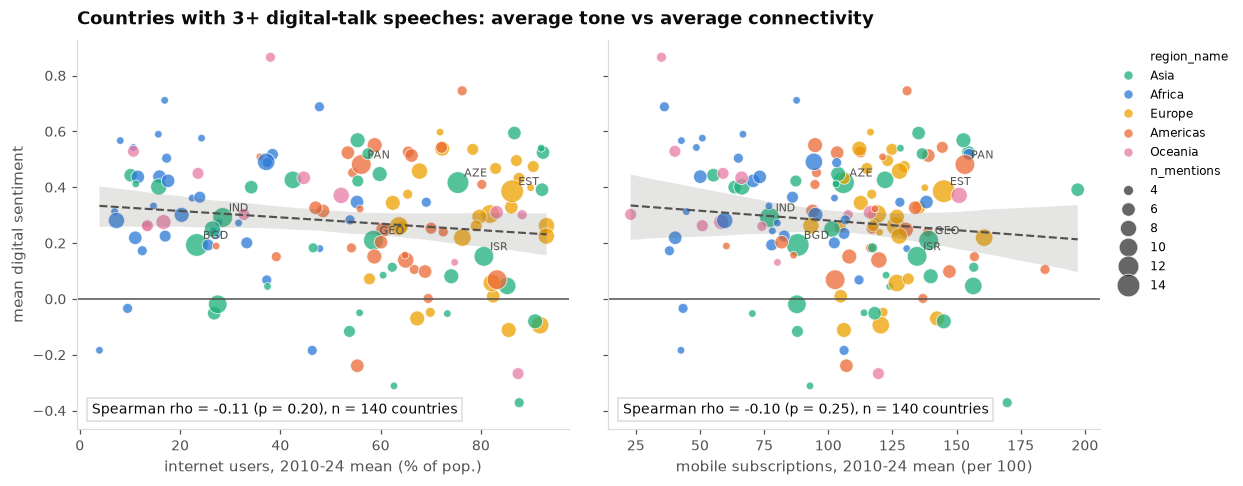

In [5]:
c = (modern[modern["year"].between(2010, 2024)]
     .groupby(["country_code", "country", "region_name"])
     .agg(sentiment=("sentiment", "mean"), n_mentions=("mention", "sum"),
          internet=("internet_users_pct", "mean"), mobile=("mobile_per_100", "mean"))
     .reset_index().query("n_mentions >= 3").dropna(subset=["internet", "sentiment"]))

regions = sorted(c["region_name"].dropna().unique())
palette = dict(zip(regions, SERIES))
label = c.nlargest(7, "n_mentions")

fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), sharey=True, gridspec_kw={"wspace": 0.08})
for ax, col, xlab in zip(axes, ["internet", "mobile"],
                         ["internet users, 2010-24 mean (% of pop.)", "mobile subscriptions, 2010-24 mean (per 100)"]):
    ax.axhline(0, color=INK_SOFT, lw=1)
    sns.scatterplot(data=c, x=col, y="sentiment", hue="region_name", palette=palette, size="n_mentions",
                    sizes=(25, 220), alpha=0.75, edgecolor="white", linewidth=0.6, ax=ax, legend=(col == "mobile"))
    sns.regplot(data=c, x=col, y="sentiment", scatter=False, color=INK_SOFT, ci=95,
                line_kws={"lw": 1.4, "ls": "--"}, ax=ax)
    rho, p = stats.spearmanr(c[col], c["sentiment"])
    ax.text(0.03, 0.04, f"Spearman rho = {rho:+.2f} (p = {p:.2f}), n = {len(c)} countries",
            transform=ax.transAxes, fontsize=9, color=INK,
            bbox={"facecolor": "white", "edgecolor": GRID, "pad": 3})
    for r in label.itertuples():
        ax.annotate(r.country_code, (getattr(r, col), r.sentiment), xytext=(4, 4), textcoords="offset points",
                    fontsize=7.5, color=INK_SOFT)
    finish(ax, None, xlabel=xlab, ylabel="mean digital sentiment" if col == "internet" else "", grid=None)
axes[0].set_title("Countries with 3+ digital-talk speeches: average tone vs average connectivity", loc="left", pad=10)
h, l = axes[1].get_legend_handles_labels()
axes[1].legend(h, l, loc="upper left", bbox_to_anchor=(1.01, 1), fontsize=8, title=None)
plt.show()

Averaging each country over 2010-24 removes some of the single-sentence noise. There is a slight downward drift (the most connected countries are a little *cooler* in tone), but it is not distinguishable from zero for either internet users (rho = -0.11, p = 0.20) or mobile subscriptions (rho = -0.10, p = 0.25). The countries that mention digital topics most often (large dots) do not cluster at either end. Every region spans nearly the whole sentiment range.

### 2.4 One picture: which speech measure lines up with which outcome?

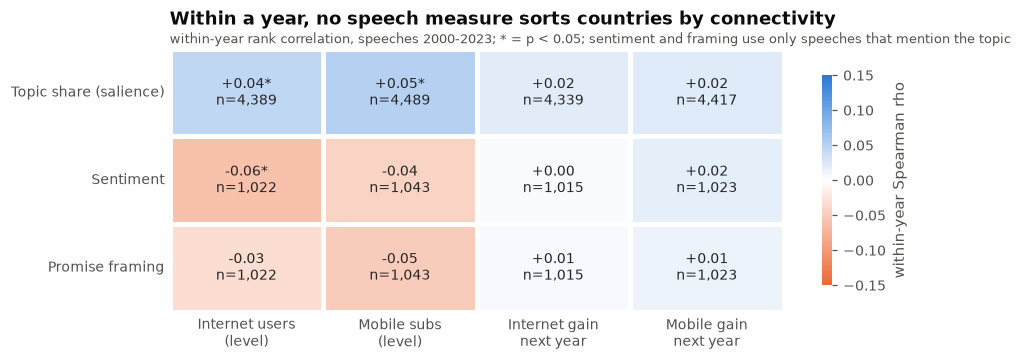

In [6]:
MEASURES = {"Topic share (salience)": "salience", "Sentiment": "sentiment", "Promise framing": "promise"}
OUTCOMES = {"Internet users\n(level)": "internet_users_pct", "Mobile subs\n(level)": "mobile_per_100",
            "Internet gain\nnext year": "internet_gain_next", "Mobile gain\nnext year": "mobile_gain_next"}

h = modern[modern["year"] <= 2023]
# Rank within each year so the common global trend cannot create a correlation by itself.
ranked = {col: h.groupby("year")[col].rank(pct=True) for col in [*MEASURES.values(), *OUTCOMES.values()]}

rho = pd.DataFrame(index=MEASURES, columns=OUTCOMES, dtype=float)
star = rho.copy().astype(object)
size = rho.copy()
for m_lab, m in MEASURES.items():
    for o_lab, o in OUTCOMES.items():
        pair = pd.concat([ranked[m], ranked[o]], axis=1).dropna()
        r, p = stats.pearsonr(pair.iloc[:, 0], pair.iloc[:, 1])
        rho.loc[m_lab, o_lab], size.loc[m_lab, o_lab] = r, len(pair)
        star.loc[m_lab, o_lab] = f"{r:+.2f}{'*' if p < 0.05 else ''}\nn={len(pair):,}"

fig, ax = plt.subplots(figsize=(9, 3.1))
sns.heatmap(rho, annot=star, fmt="", cmap=DIVERGING, vmin=-0.15, vmax=0.15, linewidths=2, linecolor="white",
            cbar_kws={"label": "within-year Spearman rho", "shrink": 0.8}, annot_kws={"fontsize": 9}, ax=ax)
ax.set_xticklabels(rho.columns, rotation=0)
finish(ax, "Within a year, no speech measure sorts countries by connectivity",
       "within-year rank correlation, speeches 2000-2023; * = p < 0.05; sentiment and framing use only speeches that mention the topic",
       grid=None)
ax.tick_params(length=0)
plt.show()

Ranking countries *within each year* strips out the shared global trend. What is left is tiny: talk volume has a rank correlation of only about +0.05 with connectivity levels (statistically detectable with 4,400 speeches, practically negligible), sentiment has a slightly *negative* one (-0.06 with internet users, -0.04 with mobile subscriptions) and none of the measures line up with next-year gains (all within +/-0.02).

### Q1 in short

* **Volume moves with connectivity; tone does not.** Digital talk becomes far more common as the world gets connected (19% to 43% of speeches), but average sentiment stays flat at about +0.3.
* **Across countries, tone and connectivity are unrelated** (|rho| about 0.1 or less, not significant), for both internet use and mobile subscriptions, in levels and in one-year changes. If anything, better-connected countries sound slightly *cooler*.
* **So the exploratory answer to "all bark, no byte?" is that bark and byte are simply uncorrelated in tone.** Positive digital rhetoric is not a marker of connected countries, and it is not a marker of countries that are catching up either.

## 3. Q2 - Predictive: does sentiment forecast next year's gain, and does corruption matter?

### 3.1 Design

* **Target:** `internet_gain_next`, the change in % of the population online from year `t` to `t+1` (percentage points).
* **Unit:** a speech (country-year), 2005-2023, restricted to speeches whose country has a corruption score, a GDP figure and a next-year internet value.
* **Speech features:** whether the country mentioned digital topics, the topic share, the sentiment and the promise framing. Sentiment and framing are set to 0 (neutral) when nothing was said, and the mention flag lets a model tell "silent" from "neutral".
* **Context features in every model:** internet level at `t`, its square, log GDP per capita and the year. Adoption follows an S-curve, so *where a country is on the curve* is the obvious predictor of its next gain, and the speeches have to add to *that*.
* **Two models:** a regularised linear model (Ridge) and a random forest, so the relationship can be linear or non-linear.
* **Validation:** repeated 5-fold cross-validation that **holds out whole countries**, so a model cannot look up a country's own history.

2,113 speeches from 150 countries, 2005-2023; 574 of them contain digital talk
mean next-year gain 2.76 pp (sd 3.39)


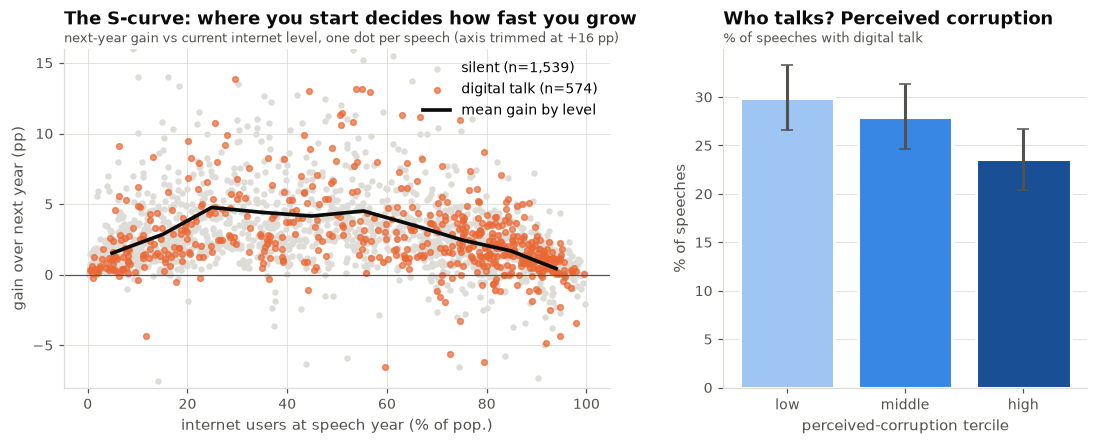

In [7]:
q2 = (panel[panel["year"].between(2005, 2023)]
      .dropna(subset=["internet_gain_next", "perceived_corruption", "internet_users_pct", "log_gdp"]).copy())
q2["internet_sq"] = q2["internet_users_pct"] ** 2 / 100
q2["sentiment_f"] = q2["sentiment"].fillna(0)
q2["promise_f"] = q2["promise"].fillna(0)

print(f"{len(q2):,} speeches from {q2['country_code'].nunique()} countries, {q2['year'].min()}-{q2['year'].max()}; "
      f"{q2['mention'].sum()} of them contain digital talk")
print(f"mean next-year gain {q2['internet_gain_next'].mean():.2f} pp (sd {q2['internet_gain_next'].std():.2f})")

fig, axes = plt.subplots(1, 2, figsize=(12, 4), gridspec_kw={"wspace": 0.25, "width_ratios": [1.5, 1]})
ax = axes[0]
quiet, talk = q2[q2["mention"] == 0], q2[q2["mention"] == 1]
ax.scatter(quiet["internet_users_pct"], quiet["internet_gain_next"], s=10, color=GRID, label=f"silent (n={len(quiet):,})")
ax.scatter(talk["internet_users_pct"], talk["internet_gain_next"], s=14, color=ORANGE, alpha=0.7,
           label=f"digital talk (n={len(talk):,})")
bins = pd.cut(q2["internet_users_pct"], np.arange(0, 101, 10), include_lowest=True)
curve = q2.groupby(bins, observed=True).agg(x=("internet_users_pct", "mean"), y=("internet_gain_next", "mean"))
ax.plot(curve["x"], curve["y"], color=INK, lw=2.4, label="mean gain by level")
ax.axhline(0, color=INK_SOFT, lw=0.8)
ax.set_ylim(-8, 16)
finish(ax, "The S-curve: where you start decides how fast you grow",
       "next-year gain vs current internet level, one dot per speech (axis trimmed at +16 pp)", xlabel="internet users at speech year (% of pop.)",
       ylabel="gain over next year (pp)", grid="both")
ax.legend(loc="upper right")

ax = axes[1]
q2["corr_tercile"] = pd.qcut(q2["perceived_corruption"], 3, labels=["low", "middle", "high"])
a = mean_ci(q2.groupby("corr_tercile", observed=True), "mention")
ax.bar(a.index, 100 * a["mean"], yerr=100 * a["ci"], color=[SEQ_BLUE[1], SEQ_BLUE[3], SEQ_BLUE[5]],
       edgecolor="white", linewidth=2, capsize=4, ecolor=INK_SOFT)
finish(ax, "Who talks? Perceived corruption", "% of speeches with digital talk", xlabel="perceived-corruption tercile",
       ylabel="% of speeches")
plt.show()

Two things to take from the pictures. **Next year's gain is mostly a function of where a country already is**: gains are largest between roughly 20% and 60% online and shrink towards saturation (so the context features will do a lot of work). And **digital talk is spread all along the curve** rather than concentrated at one end; it is a little more common in low-corruption countries (about 30% of speeches vs 23% in the high-corruption tercile), which is a first hint that corruption relates to the talk itself.

### 3.2 Feature sets and models

In [8]:
CONTEXT = ["internet_users_pct", "internet_sq", "log_gdp"]
SENT = ["mention", "sentiment_f"]
TALK = ["mention", "salience", "sentiment_f", "promise_f"]
CORR = ["perceived_corruption"]

z = q2.copy()
for col in ["internet_users_pct", "internet_sq", "log_gdp", "salience", "sentiment_f", "promise_f", "perceived_corruption"]:
    z[col] = zscore(z[col])
for col in TALK:                                  # moderation terms: every speech feature x corruption
    z[f"{col}_x_corr"] = z[col] * z["perceived_corruption"]
INTER = [f"{col}_x_corr" for col in TALK]

FEATURE_SETS = {
    "A. context only": CONTEXT,
    "B. + sentiment": CONTEXT + SENT,
    "C. + all talk (topic share, framing)": CONTEXT + TALK,
    "D. + corruption": CONTEXT + TALK + CORR,
    "E. + talk x corruption": CONTEXT + TALK + CORR + INTER,
}
MODELS = {
    "Ridge (linear)": lambda: Ridge(alpha=10.0),
    "Random forest": lambda: RandomForestRegressor(n_estimators=250, min_samples_leaf=10, max_features=0.5,
                                                   random_state=0, n_jobs=-1),
}
YEARS = np.array(sorted(z["year"].unique()))


def design(cols, model):
    """Feature matrix: the chosen columns plus the year (dummies for Ridge, a number for the forest)."""
    X = z[cols].to_numpy(float)
    if model.startswith("Ridge"):
        return np.column_stack([X, (z["year"].to_numpy()[:, None] == YEARS[1:]).astype(float)])
    return np.column_stack([X, z["year"].to_numpy(float)])


def cv_scores(X, y, groups, make, repeats=8, folds=5):
    """Out-of-sample R2 and MAE with whole countries held out, repeated with different splits."""
    r2, mae = [], []
    for seed in range(repeats):
        pred = np.empty(len(y))
        for tr, te in GroupKFold(folds, shuffle=True, random_state=seed).split(X, y, groups):
            pred[te] = make().fit(X[tr], y[tr]).predict(X[te])
        r2.append(r2_score(y, pred))
        mae.append(mean_absolute_error(y, pred))
    return np.array(r2), np.array(mae)


y, groups = z["internet_gain_next"].to_numpy(float), z["country_code"].to_numpy()
rows = []
for model, make in MODELS.items():
    for name, cols in FEATURE_SETS.items():
        if model == "Random forest" and name.startswith("E"):
            continue                              # trees find interactions themselves; E would repeat D
        r2, mae = cv_scores(design(cols, model), y, groups, make)
        rows.append({"model": model, "features": name, "R2": r2.mean(), "R2 sd": r2.std(), "MAE (pp)": mae.mean()})
cv = pd.DataFrame(rows)
print(f"baseline MAE of always predicting the mean: {mean_absolute_error(y, np.full(len(y), y.mean())):.2f} pp\n")
print(cv.to_string(index=False))

baseline MAE of always predicting the mean: 2.20 pp

         model                             features    R2  R2 sd  MAE (pp)
Ridge (linear)                      A. context only 0.184  0.002     1.875
Ridge (linear)                       B. + sentiment 0.183  0.002     1.878
Ridge (linear) C. + all talk (topic share, framing) 0.181  0.003     1.884
Ridge (linear)                      D. + corruption 0.179  0.003     1.887
Ridge (linear)               E. + talk x corruption 0.180  0.003     1.893
 Random forest                      A. context only 0.179  0.008     1.865
 Random forest                       B. + sentiment 0.183  0.007     1.857
 Random forest C. + all talk (topic share, framing) 0.184  0.008     1.858
 Random forest                      D. + corruption 0.185  0.005     1.861


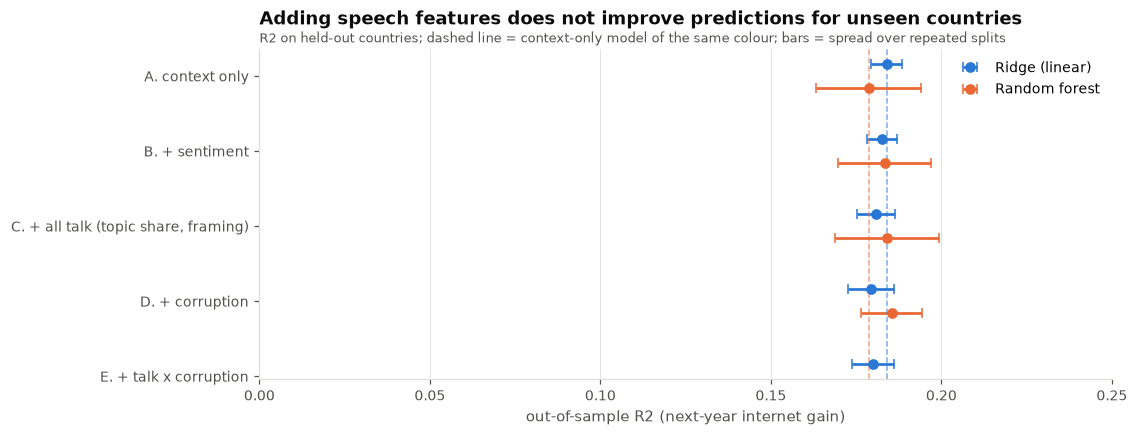

In [9]:
fig, ax = plt.subplots(figsize=(10, 3.9))
order = list(FEATURE_SETS)
ypos = np.arange(len(order))[::-1]
for model, color, off in zip(MODELS, [BLUE, ORANGE], [0.16, -0.16]):
    s = cv[cv["model"] == model].set_index("features").reindex(order)
    ok = s["R2"].notna().to_numpy()
    ax.errorbar(s["R2"][ok], (ypos + off)[ok], xerr=1.96 * s["R2 sd"][ok], fmt="o", color=color, capsize=3, lw=1.8,
                label=model)
base = cv.groupby("model")["R2"].first()
for model, color in zip(MODELS, [BLUE, ORANGE]):
    ax.axvline(base[model], color=color, lw=1, ls="--", alpha=0.6)
ax.set_yticks(ypos, order)
ax.set_xlim(0, 0.25)
finish(ax, "Adding speech features does not improve predictions for unseen countries",
       "R2 on held-out countries; dashed line = context-only model of the same colour; bars = spread over repeated splits",
       xlabel="out-of-sample R2 (next-year internet gain)", legend=True, grid="x")
plt.show()

Every feature set lands at an out-of-sample R2 of about 0.18 with either model, and the mean absolute error stays at 1.86-1.89 pp, against 2.20 pp for always guessing the average gain. **All of that predictive power comes from the context** (internet level, GDP, year), the S-curve seen above. Sentiment, topic share, framing, corruption and their interactions move R2 by less than 0.01, well inside the split-to-split noise, and for the linear model the extra features slightly *hurt* (they add variance and no signal). The random forest, which can find any non-linear pattern, does no better.

### 3.3 What do the coefficients say? (and the moderation question)

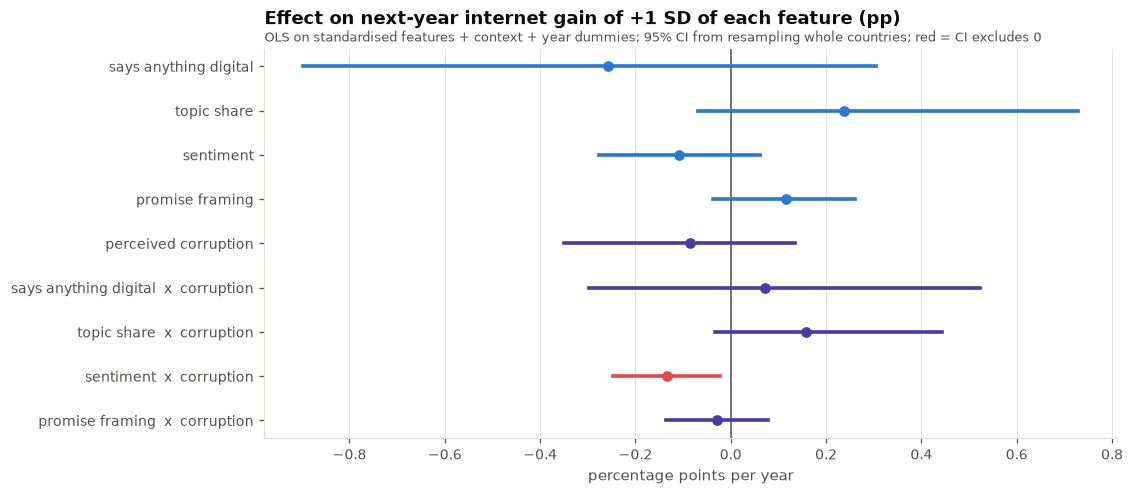

                                       coef     lo     hi
says anything digital                -0.257 -0.897  0.304
topic share                           0.237 -0.068  0.729
sentiment                            -0.108 -0.277  0.061
promise framing                       0.115 -0.038  0.261
perceived corruption                 -0.086 -0.349  0.135
says anything digital  x  corruption  0.072 -0.297  0.524
topic share  x  corruption            0.157 -0.033  0.443
sentiment  x  corruption             -0.135 -0.246 -0.022
promise framing  x  corruption       -0.028 -0.136  0.079


In [10]:
# Interpretable version of model E: plain OLS on standardised features, uncertainty by resampling whole countries.
cols_E = CONTEXT + TALK + CORR + INTER
XE = np.column_stack([np.ones(len(z)), design(cols_E, "Ridge (linear)")])
names = ["const", *cols_E, *[f"year_{yr}" for yr in YEARS[1:]]]
beta = np.linalg.lstsq(XE, y, rcond=None)[0]

rng = np.random.default_rng(0)
by_country = {c: np.flatnonzero(groups == c) for c in np.unique(groups)}
keys = np.array(list(by_country))
boot = np.empty((600, len(beta)))
for b in range(len(boot)):
    idx = np.concatenate([by_country[c] for c in rng.choice(keys, len(keys))])
    boot[b] = np.linalg.lstsq(XE[idx], y[idx], rcond=None)[0]

show = [*TALK, *CORR, *INTER]
pretty = {"mention": "says anything digital", "salience": "topic share", "sentiment_f": "sentiment",
          "promise_f": "promise framing", "perceived_corruption": "perceived corruption"}
labels = [pretty.get(c, pretty.get(c.replace("_x_corr", ""), c) + "  x  corruption") for c in show]
coef = pd.DataFrame({"coef": [beta[names.index(c)] for c in show],
                     "lo": [np.percentile(boot[:, names.index(c)], 2.5) for c in show],
                     "hi": [np.percentile(boot[:, names.index(c)], 97.5) for c in show]}, index=labels)

fig, ax = plt.subplots(figsize=(10, 4.6))
ypos = np.arange(len(coef))[::-1]
ax.axvline(0, color=INK_SOFT, lw=1)
for yv, (lab, r) in zip(ypos, coef.iterrows()):
    sig = not (r["lo"] <= 0 <= r["hi"])
    color = RED if sig else (BLUE if "corruption" not in lab else VIOLET)
    ax.plot([r["lo"], r["hi"]], [yv, yv], color=color, lw=2.4)
    ax.plot(r["coef"], yv, "o", color=color)
ax.set_yticks(ypos, coef.index)
finish(ax, "Effect on next-year internet gain of +1 SD of each feature (pp)",
       "OLS on standardised features + context + year dummies; 95% CI from resampling whole countries; red = CI excludes 0",
       xlabel="percentage points per year", grid="x")
plt.show()
print(coef.round(3).to_string())

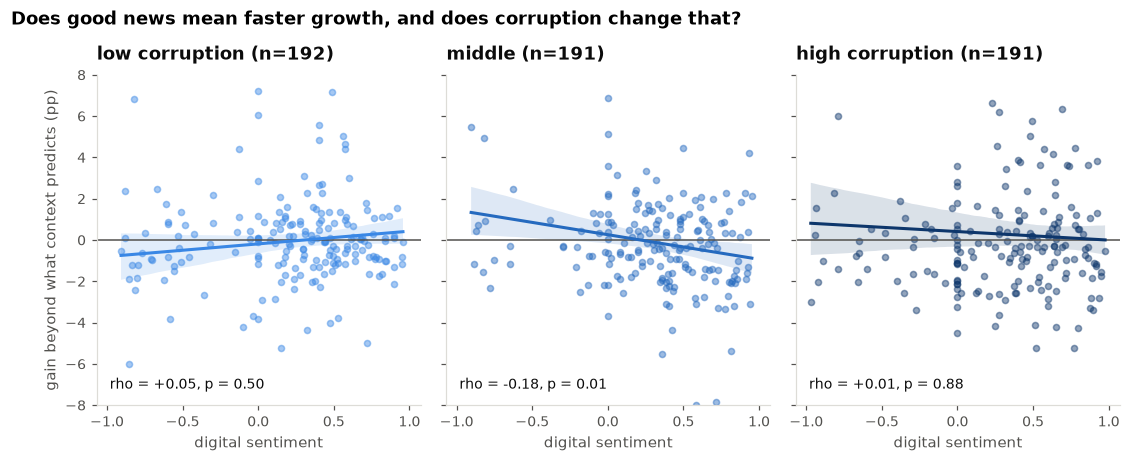

In [11]:
# Moderation, visually: strip out what the context already explains, then ask how the leftover gain
# relates to sentiment within each corruption tercile.
Xc = np.column_stack([np.ones(len(z)), design(CONTEXT, "Ridge (linear)")])
q2["gain_resid"] = y - Xc @ np.linalg.lstsq(Xc, y, rcond=None)[0]

t = q2[q2["mention"] == 1].copy()
t["corr_tercile"] = pd.qcut(t["perceived_corruption"], 3, labels=["low corruption", "middle", "high corruption"])

fig, axes = plt.subplots(1, 3, figsize=(12, 3.9), sharex=True, sharey=True, gridspec_kw={"wspace": 0.08})
for ax, (name, g), color in zip(axes, t.groupby("corr_tercile", observed=True), [SEQ_BLUE[3], SEQ_BLUE[4], SEQ_BLUE[6]]):
    ax.axhline(0, color=INK_SOFT, lw=1)
    sns.regplot(data=g, x="sentiment", y="gain_resid", color=color, ci=95, ax=ax,
                scatter_kws={"s": 16, "alpha": 0.45}, line_kws={"lw": 2})
    r, p = stats.spearmanr(g["sentiment"], g["gain_resid"])
    ax.text(0.04, 0.05, f"rho = {r:+.2f}, p = {p:.2f}", transform=ax.transAxes, fontsize=9, color=INK)
    finish(ax, f"{name} (n={len(g)})", xlabel="digital sentiment", ylabel="gain beyond what context predicts (pp)" if name.startswith("low") else "",
           grid=None)
ax.set_ylim(-8, 8)
fig.suptitle("Does good news mean faster growth, and does corruption change that?", x=0.06, ha="left",
             fontsize=12, fontweight="semibold", y=1.03)
plt.show()

Because the coefficients are standardised, "+1 SD" is comparable across rows. Sentiment's own effect is small and not distinguishable from zero (-0.11 pp per SD, 95% CI -0.28 to +0.06) against an average gain of 2.8 pp a year. One term stands out: **sentiment x corruption is negative** (-0.14 pp, CI -0.25 to -0.02). Read it as: where perceived corruption is high, warmer digital talk goes with *slightly slower* gains than the context predicts, and where it is low, with slightly faster ones. That is the "bark without byte" pattern the question anticipated.

But look at the tercile plot above before trusting it. Splitting speeches into corruption terciles, the slope is only negative in the *middle* tercile (rho = -0.18, p = 0.01); it is about zero in the low (+0.05) and high (+0.01) terciles. A true moderation effect should grow steadily from one end to the other. This one does not, and the interaction is one of nine coefficients shown (about one "significant" result is what chance alone would give).

### Q2 in short

* **Prediction: essentially no.** Sentiment, topic share and framing add nothing to a model that already knows a country's internet level, income and the year: out-of-sample R2 stays at about 0.18 for held-out countries, with a linear model and a random forest alike. Where a country is on the S-curve predicts next year's gain; what its representative says in September does not.
* **Corruption as a moderator: a hint, not a finding.** The sentiment x corruption interaction has the direction the "trust" story suggests (upbeat talk, slower gains, where corruption is high) and its bootstrap CI excludes zero, but its size is around a tenth of a percentage point, it does not show up in the tercile split as a steady trend, and adding it does not improve out-of-sample predictions.

## 4. Conclusions and limitations

### The answer to "All bark and no byte?"

**In this corpus the bark and the byte live in separate worlds.** Countries talk far more about digital infrastructure than they used to (19% to 43% of speeches) while connectivity rose everywhere, but *how positively* a country speaks tells us essentially nothing about how much connectivity it has (Q1) or how quickly it will gain more (Q2). Optimism is not a leading indicator of delivery, and pessimism is not a warning sign. The one whisper of the "restoring trust" story is that upbeat talk goes with slightly slower gains among countries perceived as more corrupt, and we would want replication before putting weight on it.

### What this analysis cannot say

* **The signal is very noisy.** The typical digital speech is one sentence long and VADER is a general-purpose sentiment model: "cyber threats" scores negative and "connectivity" scores neutral whether or not the country is delivering. Measurement error like this shrinks relationships towards zero, so "no relationship" partly reflects a blunt instrument. The confidence intervals are the honest summary: they rule out large effects, not small ones.
* **Selection.** Sentiment only exists when a country chose to speak about digital topics, and that choice is itself related to connectivity. The measures defined for every speech (topic share, mention) point the same way.
* **A speech is not a policy.** One official speaks once a year for a whole government, while the internet gain reflects years of investment, private telecom markets and foreign firms. The analysis is associational; it does not identify cause.
* **Outcome data.** The World Bank internet-user series is survey-based or modelled for many countries and is revised; 2025 has no data yet, so predictions stop at 2023 speeches.
* **Corruption is a perception**, from a citizen survey (World Happiness Report), available from 2005 only.
* **Pooled lexicon.** The digital lexicons are hand-built and pooled by adding sentence counts; a few terms (*grid*, *web*, *satellite*, *universal access*) can fire outside a digital context. `technology-sdg9.ipynb` and `all-bark-no-byte.ipynb` test this more thoroughly, along with placebo years and permutation tests.